# Analiza sieci społeczności muzycznych Reddita

Notebook przedstawia relacje między użytkownikami czterech społeczności muzycznych: Metal, Hip-hop, Indie i Pop. Celem jest sprawdzenie, kto najczęściej wchodzi w rozmowy z innymi, gdzie dyskusje skupiają się wokół kilku aktywnych osób, a gdzie aktywność jest bardziej rozproszona.

## Założenia analizy sieciowej

W analizie każdy użytkownik jest traktowany jako punkt w sieci, a odpowiedź na komentarz innej osoby tworzy relację między autorami. Jeżeli ta sama para użytkowników rozmawia ze sobą częściej, relacja ma większą wagę.

Taki graf nie pokazuje całej aktywności na Reddicie, ale pozwala zobaczyć strukturę rozmów: czy dyskusja jest rozproszona, czy skupia się wokół mniejszej grupy uczestników oraz którzy autorzy łączą różne części rozmowy.

Interpretacja grafu:

- większa liczba relacji oznacza intensywniejsze rozmowy między użytkownikami,
- wysoki stopień oznacza wielu bezpośrednich partnerów rozmowy,
- użytkownicy o wysokiej wartości betweenness mogą pełnić rolę pomostów między grupami,
- wykryte grupy pokazują użytkowników częściej rozmawiających ze sobą niż z resztą sieci.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from pathlib import Path
from collections import Counter
from itertools import combinations

try:
    from community import community_louvain

    LOUVAIN_AVAILABLE = True
except ImportError:
    community_louvain = None
    LOUVAIN_AVAILABLE = False

try:
    import plotly.graph_objects as go

    PLOTLY_AVAILABLE = True
except ImportError:
    go = None
    PLOTLY_AVAILABLE = False

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
OUTPUTS_DIR = BASE_DIR / "outputs"

FIGURES_DIR = OUTPUTS_DIR / "figures"
REPORTS_DIR = OUTPUTS_DIR / "reports"
CHECKPOINT_DIR = DATA_DIR / "checkpoints"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "processed" / "all_subreddits_sample.csv"

SUBREDDIT_LABELS = {
    "Metal": "Metal",
    "hiphopheads": "Hip-hop",
    "popheads": "Pop",
    "indieheads": "Indie",
}

def subreddit_display(name: str) -> str:
    return SUBREDDIT_LABELS.get(str(name), str(name))

def save_plotly_png(figure, filename: str) -> None:
    try:
        figure.write_image(FIGURES_DIR / filename)
    except Exception as exc:
        print(f"Nie zapisano wykresu Plotly do PNG ({filename}): {exc}")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

df = pd.read_csv(DATA_PATH)

required_columns = {"author", "parent_id", "comment_id", "subreddit"}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Brakuje wymaganych kolumn: {missing_columns}")

df = df.copy()
df["author"] = df["author"].astype(str)
df["parent_id"] = df["parent_id"].astype(str)
df["comment_id"] = df["comment_id"].astype(str)
df["subreddit"] = df["subreddit"].astype(str)

bot_pattern = r"bot$|automod|moderator|transcrib|helper"
valid_mask = (
    df["author"].notna()
    & ~df["author"].isin(["[deleted]", "[removed]", "nan", "None"])
    & ~df["author"].str.lower().str.contains(bot_pattern, regex=True, na=False)
)
df = df.loc[valid_mask].copy()

summary = pd.DataFrame(
    {
        "wartość": [
            len(df),
            df["author"].nunique(),
            df["subreddit"].nunique(),
            ", ".join(subreddit_display(name) for name in sorted(df["subreddit"].unique())),
        ]
    },
    index=[
        "liczba komentarzy po czyszczeniu",
        "liczba unikalnych użytkowników",
        "liczba społeczności",
        "analizowane społeczności",
    ],
)

summary.to_csv(REPORTS_DIR / "network_dataset_summary.csv")
summary

,wartość
liczba komentarzy po czyszczeniu,2541741
liczba unikalnych użytkowników,201615
liczba społeczności,4
analizowane społeczności,"Metal, Hip-hop, Indie, Pop"


In [2]:
# Wczytanie oczyszczonego df z checkpointu (jeśli dostępny)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
df_checkpoint_path = CHECKPOINT_DIR / "network_df_checkpoint.pkl"
if "df" in globals():
    print("df już istnieje w pamięci — pomijam wczytywanie checkpointu.")
elif df_checkpoint_path.exists():
    df = pd.read_pickle(df_checkpoint_path)
    print(f"Wczytano df z: {df_checkpoint_path}")
    print(f"df shape: {df.shape}")
    print(f"Kolumny: {df.columns.tolist()}")
else:
    print(f"Brak checkpointu: {df_checkpoint_path}")

df już istnieje w pamięci — pomijam wczytywanie checkpointu.


Wstępne czyszczenie usuwa konta techniczne, boty oraz komentarze bez użytecznego autora. Dzięki temu dalsze metryki odnoszą się przede wszystkim do realnych interakcji użytkowników, a nie do automatycznych odpowiedzi systemowych.

## 1. Budowa grafów interakcji

In [3]:
replies = df[df['parent_id'].str.startswith('t1_', na=False)].copy()
replies['parent_comment_id'] = replies['parent_id'].str.replace('t1_', '', regex=False)

edges = replies.merge(
    df[['comment_id', 'author']].rename(columns={'author': 'parent_author'}),
    left_on='parent_comment_id',
    right_on='comment_id',
    how='inner'
)

# Usuwamy odpowiedzi użytkownika do samego siebie, ponieważ nie tworzą relacji społecznej.
edges = edges[edges['author'] != edges['parent_author']].copy()

# Agregujemy powtarzające się odpowiedzi tej samej pary użytkowników.
weighted_edges = (
    edges
    .groupby(['subreddit', 'author', 'parent_author'], as_index=False)
    .size()
    .rename(columns={'size': 'weight'})
)

weighted_edges.to_csv(REPORTS_DIR / 'weighted_network_edges.csv', index=False)
weighted_edges.head(10)

,subreddit,author,parent_author,weight
0,Metal,---________----,Anrod459,1
1,Metal,---________----,C0rona,1
2,Metal,-AestheticsOfHate-,Sev_Obzen,2
3,Metal,-AestheticsOfHate-,thr33beggars,1
4,Metal,-Bunny-,meshuggahnaut,1
5,Metal,-Damien-,_lurpak_,1
6,Metal,-Davo,Krakenborn,1
7,Metal,-Davo,ManDe1orean,1
8,Metal,-Davo,cat_intervention,1
9,Metal,-Davo,one_fishBoneFish,1


In [4]:
graphs = {}
for subreddit, group in weighted_edges.groupby('subreddit'):
    graph = nx.DiGraph()
    for row in group.itertuples(index=False):
        graph.add_edge(row.author, row.parent_author, weight=int(row.weight))
    graphs[subreddit] = graph

network_overview = pd.DataFrame([
    {
        'subreddit': subreddit,
        'nodes': graph.number_of_nodes(),
        'edges': graph.number_of_edges(),
        'weighted_interactions': sum(data['weight'] for _, _, data in graph.edges(data=True))
    }
    for subreddit, graph in graphs.items()
]).sort_values('subreddit')

network_overview.to_csv(REPORTS_DIR / 'network_overview.csv', index=False)
network_overview

,subreddit,nodes,edges,weighted_interactions
0,Metal,10996,45461,59861
1,hiphopheads,83153,617923,823285
2,indieheads,32131,142887,219390
3,popheads,27142,317417,436020


In [5]:
# Wczytanie grafów z checkpointu (jeśli potrzebne)
import pickle

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
graphs_checkpoint_path = CHECKPOINT_DIR / "network_graphs_checkpoint.pkl"
if all(name in globals() for name in ["weighted_edges", "graphs", "network_overview"]):
    print("Grafy i krawędzie już istnieją w pamięci — pomijam wczytywanie checkpointu.")
elif graphs_checkpoint_path.exists():
    with open(graphs_checkpoint_path, "rb") as handle:
        checkpoint = pickle.load(handle)
    weighted_edges = checkpoint.get("weighted_edges")
    graphs = checkpoint.get("graphs", {})
    network_overview = checkpoint.get("network_overview")
    print(f"Wczytano grafy z: {graphs_checkpoint_path}")
    print(f"Liczba grafów: {len(graphs)}")
    if hasattr(weighted_edges, "shape"):
        print(f"weighted_edges shape: {weighted_edges.shape}")
    if hasattr(network_overview, "shape"):
        print(f"network_overview shape: {network_overview.shape}")
else:
    print(f"Brak checkpointu: {graphs_checkpoint_path}")

Grafy i krawędzie już istnieją w pamięci — pomijam wczytywanie checkpointu.


In [6]:
# Zapis grafów do checkpointu
import pickle

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
graphs_checkpoint_path = CHECKPOINT_DIR / "network_graphs_checkpoint.pkl"
with open(graphs_checkpoint_path, "wb") as handle:
    pickle.dump(
        {
            "weighted_edges": weighted_edges,
            "graphs": graphs,
            "network_overview": network_overview,
        },
        handle,
    )

print(f"Zapisano grafy do: {graphs_checkpoint_path}")
print(f"Liczba grafów: {len(graphs)}")
print(f"weighted_edges shape: {weighted_edges.shape}")
print(f"network_overview shape: {network_overview.shape}")

Zapisano grafy do: ..\data\checkpoints\network_graphs_checkpoint.pkl
Liczba grafów: 4
weighted_edges shape: (1123688, 4)
network_overview shape: (4, 4)


Tabela pokazuje podstawowy rozmiar sieci dla poszczególnych społeczności. Liczba relacji oznacza liczbę unikalnych połączeń między parami użytkowników, natomiast liczba ważonych interakcji uwzględnia powtarzające się odpowiedzi między tymi samymi osobami.

## 2. Podstawowe statystyki sieci

In [7]:
def safe_largest_component_size(graph_undirected):
    if graph_undirected.number_of_nodes() == 0:
        return 0
    return len(max(nx.connected_components(graph_undirected), key=len))

basic_metrics = []
for subreddit, graph in graphs.items():
    graph_undirected = graph.to_undirected()
    degrees = [degree for _, degree in graph_undirected.degree()]
    components = list(nx.connected_components(graph_undirected)) if graph_undirected.number_of_nodes() > 0 else []
    basic_metrics.append({
        'subreddit': subreddit,
        'nodes': graph.number_of_nodes(),
        'edges': graph.number_of_edges(),
        'avg_degree': round(float(np.mean(degrees)), 3) if degrees else 0,
        'max_degree': max(degrees) if degrees else 0,
        'density': round(nx.density(graph_undirected), 6),
        'connected_components': len(components),
        'largest_component_size': safe_largest_component_size(graph_undirected),
        'largest_component_share': round(safe_largest_component_size(graph_undirected) / graph.number_of_nodes(), 4) if graph.number_of_nodes() else 0
    })

basic_metrics_df = pd.DataFrame(basic_metrics).sort_values('subreddit')
basic_metrics_df.to_csv(REPORTS_DIR / 'network_basic_metrics.csv', index=False)
basic_metrics_df

,subreddit,nodes,edges,avg_degree,max_degree,density,connected_components,largest_component_size,largest_component_share
0,Metal,10996,45461,6.371,440,0.000579,286,10385,0.9444
1,hiphopheads,83153,617923,11.960,4327,0.000144,668,81753,0.9832
2,indieheads,32131,142887,6.978,961,0.000217,568,30905,0.9618
3,popheads,27142,317417,18.537,2209,0.000683,199,26700,0.9837


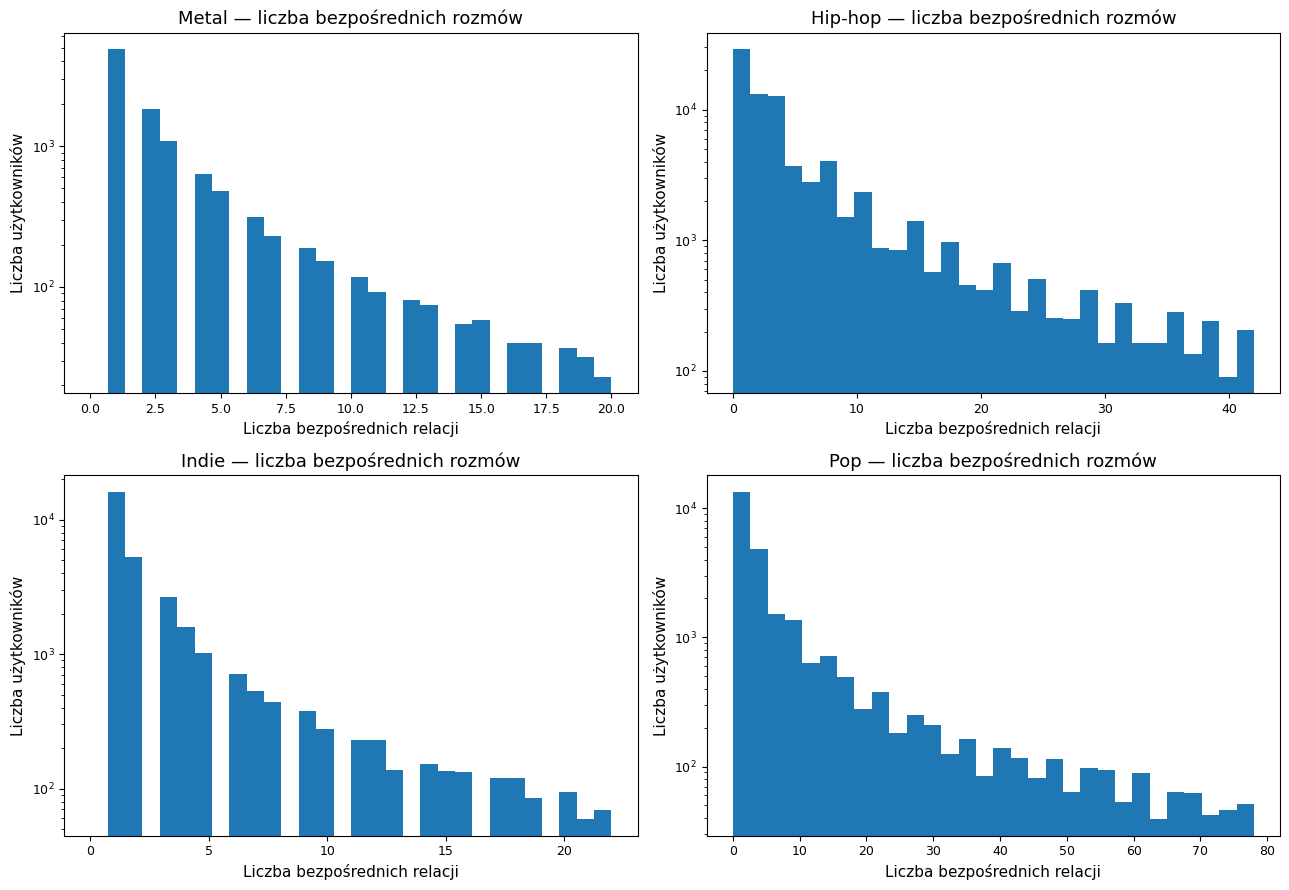

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (subreddit, graph) in zip(axes, sorted(graphs.items())):
    degrees = [degree for _, degree in graph.to_undirected().degree()]
    if not degrees:
        ax.set_title(f"{subreddit_display(subreddit)} — brak danych")
        ax.axis("off")
        continue
    upper_limit = max(1, int(np.percentile(degrees, 95)))
    ax.hist(degrees, bins=30, range=(0, upper_limit))
    ax.set_title(f"{subreddit_display(subreddit)} — liczba bezpośrednich rozmów")
    ax.set_xlabel("Liczba bezpośrednich relacji")
    ax.set_ylabel("Liczba użytkowników")
    ax.set_yscale("log")

for ax in axes[len(graphs):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "degree_distribution_networks.png", dpi=150, bbox_inches="tight")
plt.show()

Ten wykres pokazuje, ilu bezpośrednich partnerów rozmowy mają użytkownicy w poszczególnych społecznościach. Jeżeli większość osób ma niewiele relacji, dyskusja jest bardziej rozproszona. Jeżeli pojawia się grupa autorów z bardzo wysoką liczbą połączeń, rozmowy mocniej skupiają się wokół aktywnych uczestników.

## 3. Analiza centralności

In [9]:
def normalize_series(series):
    max_value = series.max()
    if pd.isna(max_value) or max_value == 0:
        return series * 0
    return series / max_value

def calculate_centralities(graph, sample_k=500, seed=42):
    if graph.number_of_nodes() == 0:
        return pd.DataFrame()
    
    degree_centrality = nx.degree_centrality(graph)
    pagerank = nx.pagerank(graph, weight='weight')
    
    k = min(sample_k, max(1, graph.number_of_nodes() - 1))
    betweenness_centrality = nx.betweenness_centrality(graph, k=k, seed=seed, weight=None)
    
    graph_undirected = graph.to_undirected()
    try:
        eigenvector_centrality = nx.eigenvector_centrality(graph_undirected, max_iter=1000, weight='weight')
    except nx.PowerIterationFailedConvergence:
        eigenvector_centrality = {node: np.nan for node in graph.nodes()}
    
    return pd.DataFrame({
        'degree_centrality': pd.Series(degree_centrality),
        'betweenness_centrality': pd.Series(betweenness_centrality),
        'eigenvector_centrality': pd.Series(eigenvector_centrality),
        'pagerank': pd.Series(pagerank)
    })

centrality_tables = {}
for subreddit, graph in graphs.items():
    centrality_df = calculate_centralities(graph)
    centrality_df['subreddit'] = subreddit
    centrality_df.index.name = 'author'
    centrality_tables[subreddit] = centrality_df

all_centralities = pd.concat(centrality_tables.values()).reset_index()
all_centralities.to_csv(REPORTS_DIR / 'network_centralities.csv', index=False)
all_centralities.head()

,author,degree_centrality,betweenness_centrality,eigenvector_centrality,pagerank,subreddit
0,---________----,0.000273,0.000065,4.711802e-05,0.000031,Metal
1,Anrod459,0.000091,0.000000,2.237331e-07,0.000034,Metal
2,C0rona,0.002183,0.000303,4.969210e-03,0.000116,Metal
3,-AestheticsOfHate-,0.000364,0.000033,7.049951e-04,0.000060,Metal
4,Sev_Obzen,0.000364,0.000000,1.647585e-05,0.000061,Metal


In [10]:
for metric in ['degree_centrality', 'betweenness_centrality', 'eigenvector_centrality', 'pagerank']:
    top_metric = (
        all_centralities
        .sort_values(['subreddit', metric], ascending=[True, False])
        .groupby('subreddit')
        .head(10)
        [['subreddit', 'author', metric]]
    )
    top_metric.to_csv(REPORTS_DIR / f'top_users_{metric}.csv', index=False)
    display(top_metric)

,subreddit,author,degree_centrality
49,Metal,whoelsebut_rxe,0.055298
104,Metal,sardonic_malcontent,0.054752
38,Metal,Towering_Flesh,0.053934
327,Metal,onairmastering,0.050568
94,Metal,an_altar_of_plagues,0.045839
154,Metal,kaptain_carbon,0.045566
197,Metal,hermaphroditicspork,0.045111
140,Metal,WowboyKid,0.043565
45,Metal,notyourlandlord,0.042565
395,Metal,Samccx19,0.041655


,subreddit,author,betweenness_centrality
49,Metal,whoelsebut_rxe,0.031067
327,Metal,onairmastering,0.030196
104,Metal,sardonic_malcontent,0.028470
38,Metal,Towering_Flesh,0.027189
154,Metal,kaptain_carbon,0.021215
395,Metal,Samccx19,0.018940
94,Metal,an_altar_of_plagues,0.018708
134,Metal,ThePiperMan,0.017837
284,Metal,JKevill,0.017720
45,Metal,notyourlandlord,0.016307


,subreddit,author,eigenvector_centrality
116,Metal,FutureWeapon,0.272859
49,Metal,whoelsebut_rxe,0.239500
140,Metal,WowboyKid,0.215428
154,Metal,kaptain_carbon,0.203477
197,Metal,hermaphroditicspork,0.190673
38,Metal,Towering_Flesh,0.188120
106,Metal,Anish316,0.183582
104,Metal,sardonic_malcontent,0.174142
1161,Metal,impop,0.174028
94,Metal,an_altar_of_plagues,0.170424


,subreddit,author,pagerank
116,Metal,FutureWeapon,0.007367
154,Metal,kaptain_carbon,0.007037
49,Metal,whoelsebut_rxe,0.006327
106,Metal,Anish316,0.005610
38,Metal,Towering_Flesh,0.005607
104,Metal,sardonic_malcontent,0.004867
197,Metal,hermaphroditicspork,0.004769
94,Metal,an_altar_of_plagues,0.004718
165,Metal,the_cramdown,0.004698
45,Metal,notyourlandlord,0.004698


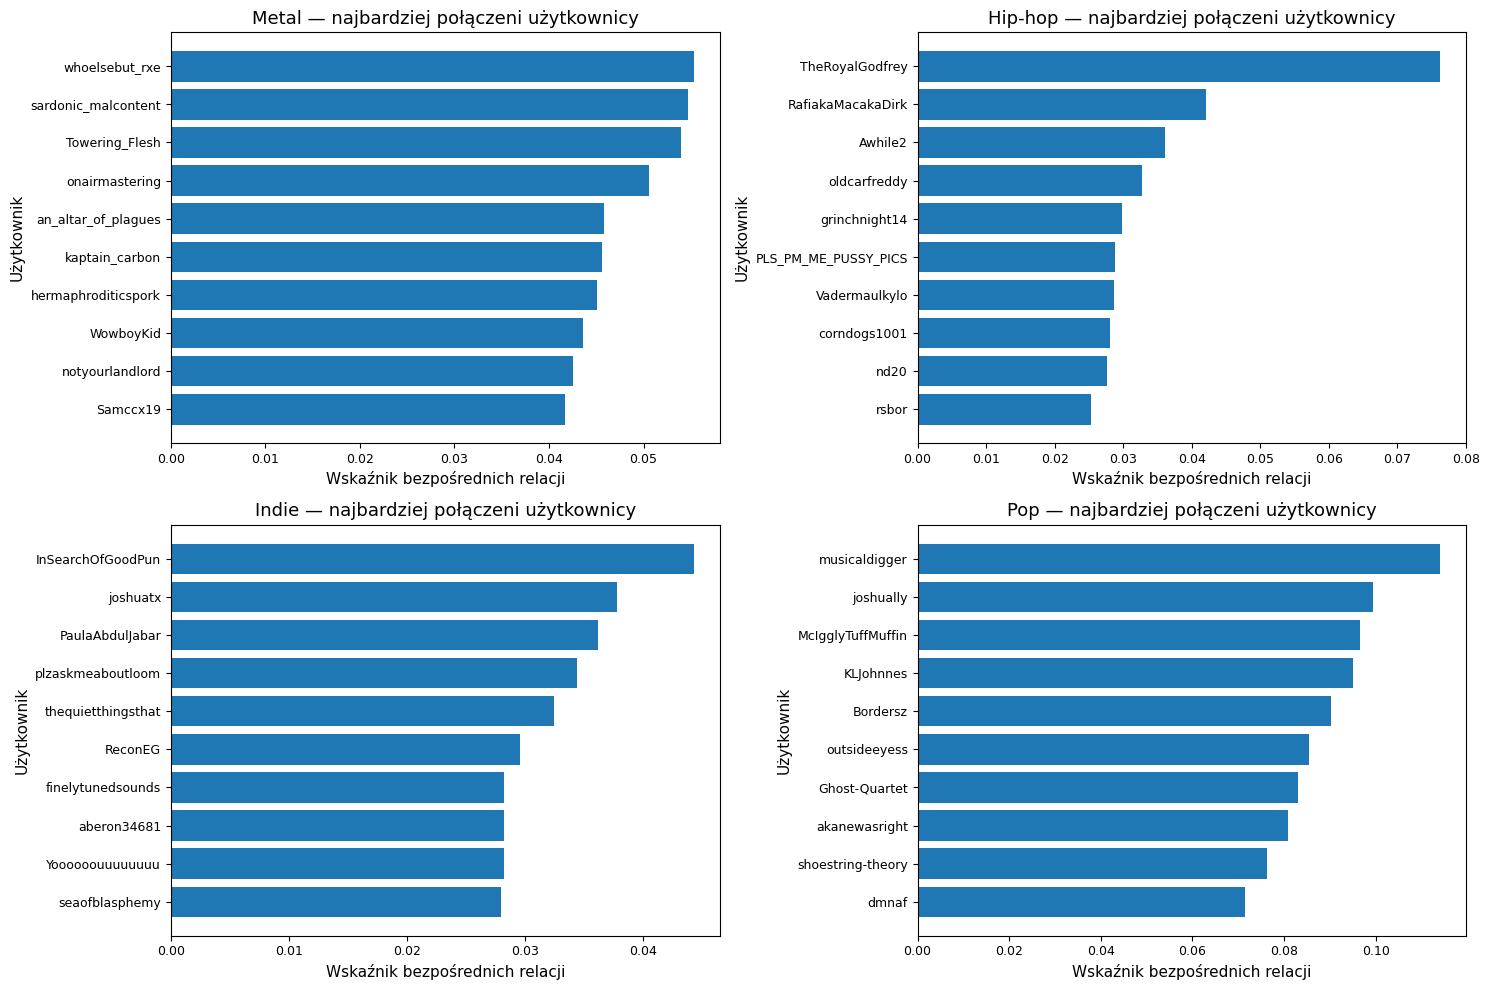

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, (subreddit, centrality_df) in zip(axes, sorted(centrality_tables.items())):
    top = centrality_df.sort_values("degree_centrality", ascending=False).head(10).iloc[::-1]
    ax.barh(top.index, top["degree_centrality"])
    ax.set_title(f"{subreddit_display(subreddit)} — najbardziej połączeni użytkownicy")
    ax.set_xlabel("Wskaźnik bezpośrednich relacji")
    ax.set_ylabel("Użytkownik")

for ax in axes[len(centrality_tables):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_degree_centrality.png", dpi=150, bbox_inches="tight")
plt.show()

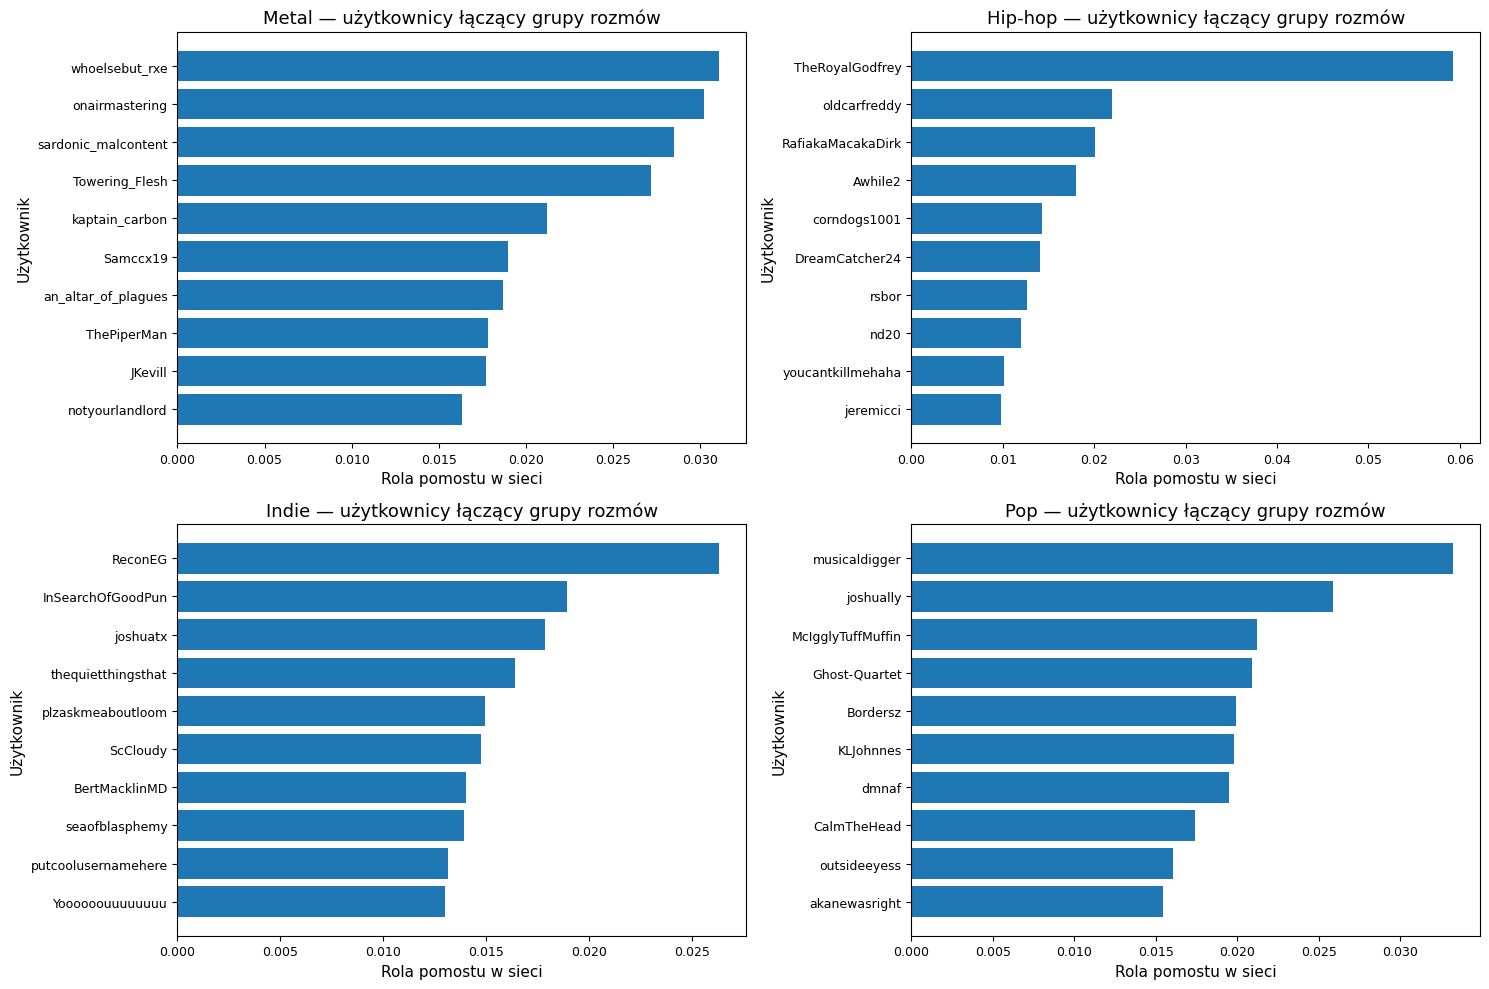

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, (subreddit, centrality_df) in zip(axes, sorted(centrality_tables.items())):
    top = centrality_df.sort_values("betweenness_centrality", ascending=False).head(10).iloc[::-1]
    ax.barh(top.index, top["betweenness_centrality"])
    ax.set_title(f"{subreddit_display(subreddit)} — użytkownicy łączący grupy rozmów")
    ax.set_xlabel("Rola pomostu w sieci")
    ax.set_ylabel("Użytkownik")

for ax in axes[len(centrality_tables):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_betweenness_centrality.png", dpi=150, bbox_inches="tight")
plt.show()

Metryki centralności są tu traktowane jako proste narzędzia do wskazania różnych ról użytkowników w rozmowach. Degree centrality pokazuje osoby mające wielu bezpośrednich partnerów dyskusji. Betweenness centrality pomaga znaleźć autorów pełniących rolę pomostów między grupami, czyli takich, którzy pojawiają się w różnych częściach sieci i mogą łączyć kilka kręgów rozmowy. Pozostałe miary są używane pomocniczo, aby nie opierać interpretacji na jednym wskaźniku.

## 4. Wykrywanie społeczności i klastrów

In [13]:
community_stats = []
community_assignments = []

for subreddit, graph in graphs.items():
    graph_undirected = graph.to_undirected()
    if graph_undirected.number_of_nodes() == 0:
        continue
    
    if LOUVAIN_AVAILABLE:
        partition = community_louvain.best_partition(graph_undirected, weight='weight', random_state=42)
        modularity = community_louvain.modularity(partition, graph_undirected, weight='weight')
        method = 'Louvain'
    else:
        communities = nx.algorithms.community.greedy_modularity_communities(graph_undirected, weight='weight')
        partition = {node: idx for idx, community in enumerate(communities) for node in community}
        modularity = nx.algorithms.community.modularity(graph_undirected, communities, weight='weight')
        method = 'greedy_modularity'
    
    nx.set_node_attributes(graph, partition, 'community')
    counts = Counter(partition.values())
    largest_communities = counts.most_common(5)
    
    community_stats.append({
        'subreddit': subreddit,
        'method': method,
        'communities': len(counts),
        'modularity': round(float(modularity), 4),
        'largest_community_size': largest_communities[0][1] if largest_communities else 0,
        'largest_community_share': round(largest_communities[0][1] / graph.number_of_nodes(), 4) if largest_communities else 0
    })
    
    for author, community_id in partition.items():
        community_assignments.append({
            'subreddit': subreddit,
            'author': author,
            'community': community_id
        })

community_stats_df = pd.DataFrame(community_stats).sort_values('subreddit')
community_assignments_df = pd.DataFrame(community_assignments)
community_stats_df.to_csv(REPORTS_DIR / 'community_detection_stats.csv', index=False)
community_assignments_df.to_csv(REPORTS_DIR / 'community_assignments.csv', index=False)
community_stats_df

,subreddit,method,communities,modularity,largest_community_size,largest_community_share
0,Metal,Louvain,330,0.3629,1086,0.0988
1,hiphopheads,Louvain,747,0.3121,19060,0.2292
2,indieheads,Louvain,726,0.4123,7917,0.2464
3,popheads,Louvain,238,0.2053,5479,0.2019


In [15]:
# Zapis wyników detekcji społeczności do checkpointu

import pickle

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

community_checkpoint_path = (
    CHECKPOINT_DIR / "community_detection_checkpoint.pkl"
)

with open(community_checkpoint_path, "wb") as handle:
    pickle.dump(
        {
            "community_stats_df": community_stats_df,
            "community_assignments_df": community_assignments_df,
        },
        handle,
    )

print(
    f"Zapisano wyniki detekcji społeczności do: "
    f"{community_checkpoint_path}"
)

Zapisano wyniki detekcji społeczności do: ..\data\checkpoints\community_detection_checkpoint.pkl


In [17]:
COMMUNITY_CHECKPOINT = (
    CHECKPOINT_DIR / "community_detection_checkpoint.pkl"
)

community_stats_df = None
community_assignments_df = None

if COMMUNITY_CHECKPOINT.exists():

    print("Wczytywanie checkpointu społeczności...")

    with open(COMMUNITY_CHECKPOINT, "rb") as handle:
        checkpoint = pickle.load(handle)

    community_stats_df = checkpoint.get(
        "community_stats_df"
    )

    community_assignments_df = checkpoint.get(
        "community_assignments_df"
    )

    if community_stats_df is not None:
        print(
            f"community_stats_df: "
            f"{community_stats_df.shape}"
        )

    if community_assignments_df is not None:
        print(
            f"community_assignments_df: "
            f"{community_assignments_df.shape}"
        )

else:
    print("Checkpoint społeczności nie istnieje.")

Wczytywanie checkpointu społeczności...
community_stats_df: (4, 6)
community_assignments_df: (153422, 3)


In [18]:
largest_communities_summary = []
for subreddit, group in community_assignments_df.groupby('subreddit'):
    counts = group['community'].value_counts().head(10)
    for community_id, size in counts.items():
        largest_communities_summary.append({
            'subreddit': subreddit,
            'community': community_id,
            'size': size
        })

largest_communities_df = pd.DataFrame(largest_communities_summary)
largest_communities_df.to_csv(REPORTS_DIR / 'largest_communities.csv', index=False)
largest_communities_df

,subreddit,community,size
0,Metal,10,1086
1,Metal,12,1053
2,Metal,9,859
3,Metal,3,767
4,Metal,27,649
5,Metal,18,582
6,Metal,11,565
7,Metal,14,435
8,Metal,8,388
9,Metal,0,362


Wykrywanie społeczności pokazuje, czy dyskusje tworzą zwarte grupy użytkowników. Wysoka modularność sugeruje silniejszy podział na klastry, natomiast niższa modularność oznacza bardziej wymieszaną strukturę rozmów. Wielkość największej społeczności pozwala ocenić, czy aktywność skupia się w jednym głównym jądrze, czy jest rozproszona między kilka grup.

## 5. Wizualizacja grafów

In [20]:
# Wizualizacja 3D — przykładowy łańcuch rozmów

def get_longest_chain_subgraph(graph, max_nodes=25):
    """Zwraca krótki, czytelny fragment rozmowy z największej części sieci."""
    graph_undirected = graph.to_undirected()

    if graph_undirected.number_of_nodes() == 0:
        return graph_undirected

    largest_component = max(nx.connected_components(graph_undirected), key=len)

    component = graph_undirected.subgraph(largest_component).copy()

    if component.number_of_nodes() < 2:
        return component

    start_node = max(component.degree(weight="weight"), key=lambda item: item[1])[0]

    bfs_tree = nx.bfs_tree(component, source=start_node).to_undirected()

    def farthest_node(tree, source):
        lengths = nx.single_source_shortest_path_length(tree, source)
        return max(lengths.items(), key=lambda item: item[1])[0]

    node_a = farthest_node(bfs_tree, start_node)
    node_b = farthest_node(bfs_tree, node_a)

    path = nx.shortest_path(bfs_tree, source=node_a, target=node_b)

    if len(path) > max_nodes:
        path = path[:max_nodes]

    chain = component.subgraph(path).copy()

    # Zostawiamy tylko relacje z wybranego łańcucha rozmowy.
    path_edges = list(zip(path[:-1], path[1:]))

    chain_clean = nx.Graph()
    chain_clean.add_nodes_from(path)

    for u, v in path_edges:
        weight = component[u][v].get("weight", 1) if component.has_edge(u, v) else 1
        chain_clean.add_edge(u, v, weight=weight)

    return chain_clean


if PLOTLY_AVAILABLE:

    for subreddit, graph in sorted(graphs.items()):

        subgraph = get_longest_chain_subgraph(graph, max_nodes=25)

        if subgraph.number_of_nodes() < 2:
            print(f"{subreddit_display(subreddit)}: za mało danych do wizualizacji.")
            continue

        positions = nx.spring_layout(subgraph, dim=3, seed=42, k=1.8)

        degrees = dict(subgraph.degree(weight="weight"))

        edge_x, edge_y, edge_z = [], [], []

        for source, target in subgraph.edges():

            x0, y0, z0 = positions[source]
            x1, y1, z1 = positions[target]

            edge_x += [x0, x1, None]
            edge_y += [y0, y1, None]
            edge_z += [z0, z1, None]

        edge_trace = go.Scatter3d(
            x=edge_x,
            y=edge_y,
            z=edge_z,
            mode="lines",
            line=dict(width=4),
            hoverinfo="none",
        )

        node_trace = go.Scatter3d(
            x=[positions[node][0] for node in subgraph.nodes()],
            y=[positions[node][1] for node in subgraph.nodes()],
            z=[positions[node][2] for node in subgraph.nodes()],
            mode="markers+text",
            text=[
                node if i in [0, len(subgraph.nodes()) - 1] else ""
                for i, node in enumerate(subgraph.nodes())
            ],
            hovertext=[f"{node}<br>liczba relacji w pokazanym fragmencie: {degrees[node]}" for node in subgraph.nodes()],
            hoverinfo="text",
            marker=dict(
                size=[8 + min(degrees[node], 10) * 2 for node in subgraph.nodes()],
                opacity=0.9,
            ),
        )

        figure = go.Figure(data=[edge_trace, node_trace])

        figure.update_layout(
            title=(
                f"{subreddit_display(subreddit)} — przykładowy łańcuch rozmów "
                f"({subgraph.number_of_nodes()} użytkowników)"
            ),
            showlegend=False,
            margin=dict(l=0, r=0, b=0, t=50),
        )

        subreddit_slug = str(subreddit).lower().replace(" ", "_").replace("/", "_")
        save_plotly_png(figure, f"network_longest_chain_3d_{subreddit_slug}.png")
        figure.show()

else:
    print("Plotly nie jest zainstalowane, dlatego pominięto wizualizację 3D.")

Nie zapisano wykresu Plotly do PNG (network_longest_chain_3d_metal.png): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



Nie zapisano wykresu Plotly do PNG (network_longest_chain_3d_hiphopheads.png): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



Nie zapisano wykresu Plotly do PNG (network_longest_chain_3d_indieheads.png): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



Nie zapisano wykresu Plotly do PNG (network_longest_chain_3d_popheads.png): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



In [21]:
# Wizualizacja 3D — użytkownicy pełniący rolę pomostów

if PLOTLY_AVAILABLE:

    for subreddit, graph in sorted(graphs.items()):

        if subreddit not in centrality_tables:
            print(f"Brak tabeli centralności dla {subreddit_display(subreddit)}.")
            continue

        centrality_df = centrality_tables[subreddit]

        top_users = (
            centrality_df.sort_values("betweenness_centrality", ascending=False)
            .head(8)
            .index
            .tolist()
        )

        subgraph = graph.to_undirected().subgraph(top_users).copy()

        if subgraph.number_of_nodes() < 2:
            print(f"{subreddit_display(subreddit)}: za mało użytkowników do wizualizacji 3D.")
            continue

        positions = nx.spring_layout(subgraph, dim=3, seed=42, k=1.8)

        communities = nx.get_node_attributes(graph, "community")

        # Relacje
        edge_x, edge_y, edge_z = [], [], []

        for source, target in subgraph.edges():

            x0, y0, z0 = positions[source]
            x1, y1, z1 = positions[target]

            edge_x += [x0, x1, None]
            edge_y += [y0, y1, None]
            edge_z += [z0, z1, None]

        edge_trace = go.Scatter3d(
            x=edge_x,
            y=edge_y,
            z=edge_z,
            mode="lines",
            line=dict(width=4),
            hoverinfo="none",
        )

        # Użytkownicy
        node_x = [positions[node][0] for node in subgraph.nodes()]
        node_y = [positions[node][1] for node in subgraph.nodes()]
        node_z = [positions[node][2] for node in subgraph.nodes()]

        node_betweenness = [
            centrality_df.loc[node, "betweenness_centrality"] for node in subgraph.nodes()
        ]

        node_degree = dict(subgraph.degree())

        node_trace = go.Scatter3d(
            x=node_x,
            y=node_y,
            z=node_z,
            mode="markers+text",
            text=list(subgraph.nodes()),
            textposition="top center",
            hovertext=[
                (
                    f"{node}<br>"
                    f"rola pomostu: {centrality_df.loc[node, 'betweenness_centrality']:.6f}<br>"
                    f"liczba relacji w pokazanym fragmencie: {node_degree[node]}<br>"
                    f"grupa w sieci: {communities.get(node, 'brak')}"
                )
                for node in subgraph.nodes()
            ],
            hoverinfo="text",
            marker=dict(
                size=[10 + value * 80 for value in node_betweenness],
                color=node_betweenness,
                opacity=0.9,
                colorbar=dict(title="Rola pomostu"),
            ),
        )

        figure = go.Figure(data=[edge_trace, node_trace])

        figure.update_layout(
            title=(
                f"{subreddit_display(subreddit)} — użytkownicy łączący różne grupy rozmów"
            ),
            showlegend=False,
            margin=dict(l=0, r=0, b=0, t=50),
        )

        subreddit_slug = str(subreddit).lower().replace(" ", "_").replace("/", "_")
        save_plotly_png(figure, f"network_top_betweenness_3d_{subreddit_slug}.png")
        figure.show()

else:
    print(
        "Plotly nie jest zainstalowane, dlatego pominięto "
        "interaktywną wizualizację 3D."
    )

Nie zapisano wykresu Plotly do PNG (network_top_betweenness_3d_metal.png): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



Nie zapisano wykresu Plotly do PNG (network_top_betweenness_3d_hiphopheads.png): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



Nie zapisano wykresu Plotly do PNG (network_top_betweenness_3d_indieheads.png): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



Nie zapisano wykresu Plotly do PNG (network_top_betweenness_3d_popheads.png): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



Wizualizacje zostały ograniczone do małych, czytelnych fragmentów sieci. Pełne grafy użytkowników są zbyt gęste, dlatego w tej części pokazane są tylko przykładowe łańcuchy rozmów oraz najważniejsi użytkownicy-pomosty. Celem tych wykresów jest ułatwienie interpretacji, a nie szczegółowe pokazanie wszystkich relacji.

## 6. Wspólni użytkownicy między społecznościami

In [23]:
# Nakładanie się użytkowników między społecznościami — diagram Sankeya

if not PLOTLY_AVAILABLE:
    print("Plotly nie jest zainstalowane, dlatego pominięto diagram Sankeya.")

else:
    subreddit_users = df.groupby("subreddit")["author"].apply(
        lambda users: set(users.dropna().astype(str))
    )

    subreddits = sorted(subreddit_users.index)

    overlap_rows = []

    for subreddit_a, subreddit_b in combinations(subreddits, 2):
        users_a = subreddit_users[subreddit_a]
        users_b = subreddit_users[subreddit_b]
        overlap = users_a & users_b

        overlap_rows.append(
            {
                "subreddit_a": subreddit_a,
                "subreddit_b": subreddit_b,
                "shared_users": len(overlap),
                "share_of_a": round(len(overlap) / len(users_a), 4) if len(users_a) else 0,
                "share_of_b": round(len(overlap) / len(users_b), 4) if len(users_b) else 0,
            }
        )

    overlap_df = pd.DataFrame(overlap_rows)

    overlap_df.to_csv(REPORTS_DIR / "cross_subreddit_user_overlap.csv", index=False)

    # Sankey używa dwóch kopii każdej społeczności: po lewej i po prawej stronie wykresu.
    left_nodes = [f"{subreddit_display(subreddit)} — grupa A" for subreddit in subreddits]
    right_nodes = [f"{subreddit_display(subreddit)} — grupa B" for subreddit in subreddits]
    labels = left_nodes + right_nodes

    label_to_id = {label: idx for idx, label in enumerate(labels)}

    sources = []
    targets = []
    values = []

    for _, row in overlap_df.iterrows():
        subreddit_a = row["subreddit_a"]
        subreddit_b = row["subreddit_b"]
        shared_users = row["shared_users"]

        if shared_users > 0:
            sources.append(label_to_id[f"{subreddit_display(subreddit_a)} — grupa A"])
            targets.append(label_to_id[f"{subreddit_display(subreddit_b)} — grupa B"])
            values.append(shared_users)

    fig = go.Figure(
        data=[
            go.Sankey(
                arrangement="snap",
                node=dict(
                    pad=18,
                    thickness=20,
                    line=dict(color="black", width=0.4),
                    label=labels,
                ),
                link=dict(
                    source=sources,
                    target=targets,
                    value=values,
                ),
            )
        ]
    )

    fig.update_layout(
        title_text="Wspólni użytkownicy między społecznościami muzycznymi",
        font_size=12,
        width=1200,
        height=650,
    )

    save_plotly_png(fig, "cross_subreddit_user_overlap_sankey.png")
    fig.show()

    overlap_display = overlap_df.copy()
    overlap_display["subreddit_a"] = overlap_display["subreddit_a"].map(subreddit_display)
    overlap_display["subreddit_b"] = overlap_display["subreddit_b"].map(subreddit_display)
    overlap_display = overlap_display.rename(
        columns={
            "subreddit_a": "społeczność A",
            "subreddit_b": "społeczność B",
            "shared_users": "wspólni użytkownicy",
            "share_of_a": "udział w A",
            "share_of_b": "udział w B",
        }
    )
    display(overlap_display)

Nie zapisano wykresu Plotly do PNG (cross_subreddit_user_overlap_sankey.png): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



,społeczność A,społeczność B,wspólni użytkownicy,udział w A,udział w B
0,Metal,Hip-hop,663,0.0390,0.0060
1,Metal,Indie,472,0.0277,0.0092
2,Metal,Pop,149,0.0088,0.0040
3,Hip-hop,Indie,5815,0.0529,0.1129
4,Hip-hop,Pop,4896,0.0445,0.1322
5,Indie,Pop,3389,0.0658,0.0915


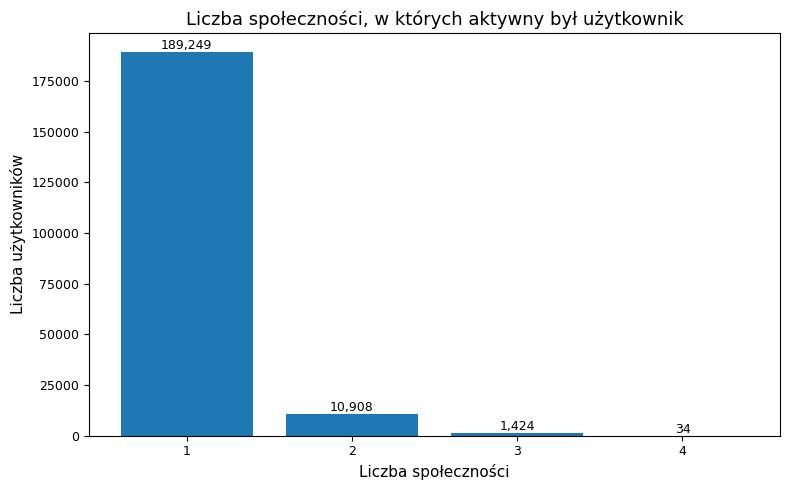

,total_comments,subreddits
author,,
MorrisFae,2205,"Hip-hop, Indie, Metal, Pop"
CaptainOvbious,1714,"Hip-hop, Indie, Metal, Pop"
Ktulusanders,1179,"Hip-hop, Indie, Metal, Pop"
riddhishb,688,"Hip-hop, Indie, Metal, Pop"
OLD_GREGG420,684,"Hip-hop, Indie, Metal, Pop"
lanternsinthesky,423,"Hip-hop, Indie, Metal, Pop"
boner_4ever,394,"Hip-hop, Indie, Metal, Pop"
MangoMiasma,292,"Hip-hop, Indie, Metal, Pop"
______________-__-,267,"Hip-hop, Indie, Metal, Pop"


In [24]:
user_subreddit_count = df.groupby('author')['subreddit'].nunique()
user_subreddit_distribution = user_subreddit_count.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(user_subreddit_distribution.index, user_subreddit_distribution.values)
ax.set_title('Liczba społeczności, w których aktywny był użytkownik')
ax.set_xlabel('Liczba społeczności')
ax.set_ylabel('Liczba użytkowników')
ax.set_xticks(user_subreddit_distribution.index)

for x, y in zip(user_subreddit_distribution.index, user_subreddit_distribution.values):
    ax.text(x, y, f'{y:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'user_subreddit_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

users_in_all_subreddits = set.intersection(*subreddit_users.tolist()) if len(subreddit_users) > 0 else set()
users_in_all_df = (
    df[df['author'].isin(users_in_all_subreddits)]
    .groupby('author')
    .agg(total_comments=('comment_id', 'count'), subreddits=('subreddit', lambda x: ', '.join(sorted(subreddit_display(name) for name in set(x)))))
    .sort_values('total_comments', ascending=False)
)
users_in_all_df.to_csv(REPORTS_DIR / 'users_active_in_all_subreddits.csv')
users_in_all_df.head(20)

Analiza wspólnych użytkowników pozwala sprawdzić, czy społeczności muzyczne są od siebie odseparowane, czy też część osób uczestniczy w kilku miejscach naraz. Tacy użytkownicy mogą przenosić style rozmowy, rekomendacje i odniesienia muzyczne między różnymi fandomami, choć sama aktywność w kilku społecznościach nie oznacza jeszcze wysokiej pozycji w sieci odpowiedzi.

## 7. Użytkownicy o najwyższej centralności w sieci

W tej części zamiast określenia „influencerzy” stosowane jest bardziej neutralne pojęcie „użytkownicy o najwyższej centralności”. Wskaźnik `influence_score` ma charakter pomocniczy. Łączy aktywność komentarzową, liczbę bezpośrednich relacji oraz rolę pomostu między grupami rozmów.

Nie należy traktować go jako miary realnego wpływu społecznego albo jakości wypowiedzi. Pokazuje jedynie, którzy autorzy są widoczni w strukturze rozmów i mogą łączyć różne fragmenty danej społeczności.

In [25]:
comment_counts = (
    df.groupby(['subreddit', 'author'])['comment_id']
    .count()
    .rename('comment_count')
    .reset_index()
)

influence_tables = []
for subreddit, centrality_df in centrality_tables.items():
    temp = centrality_df.reset_index().merge(
        comment_counts[comment_counts['subreddit'] == subreddit],
        on=['subreddit', 'author'],
        how='left'
    )
    temp['comment_count'] = temp['comment_count'].fillna(0)
    
    for column in ['degree_centrality', 'betweenness_centrality', 'comment_count']:
        temp[f'{column}_norm'] = normalize_series(temp[column])
    
    temp['influence_score'] = temp[[
        'degree_centrality_norm',
        'betweenness_centrality_norm',
        'comment_count_norm'
    ]].mean(axis=1)
    influence_tables.append(temp)

influence_df = pd.concat(influence_tables, ignore_index=True)
influence_df.to_csv(REPORTS_DIR / 'network_influence_score.csv', index=False)

top_influence_df = (
    influence_df
    .sort_values(['subreddit', 'influence_score'], ascending=[True, False])
    .groupby('subreddit')
    .head(10)
)
top_influence_df.to_csv(REPORTS_DIR / 'top_structurally_central_users.csv', index=False)
top_influence_df[['subreddit', 'author', 'degree_centrality', 'betweenness_centrality', 'comment_count', 'influence_score']]

,subreddit,author,degree_centrality,betweenness_centrality,comment_count,influence_score
49,Metal,whoelsebut_rxe,0.055298,0.031067,942,0.982245
327,Metal,onairmastering,0.050568,0.030196,995,0.962153
104,Metal,sardonic_malcontent,0.054752,0.028470,849,0.919937
38,Metal,Towering_Flesh,0.053934,0.027189,895,0.916670
154,Metal,kaptain_carbon,0.045566,0.021215,841,0.784039
94,Metal,an_altar_of_plagues,0.045839,0.018708,723,0.719261
140,Metal,WowboyKid,0.043565,0.015425,766,0.684729
197,Metal,hermaphroditicspork,0.045111,0.015341,731,0.681430
395,Metal,Samccx19,0.041655,0.018940,593,0.652975
134,Metal,ThePiperMan,0.040382,0.017837,603,0.636818


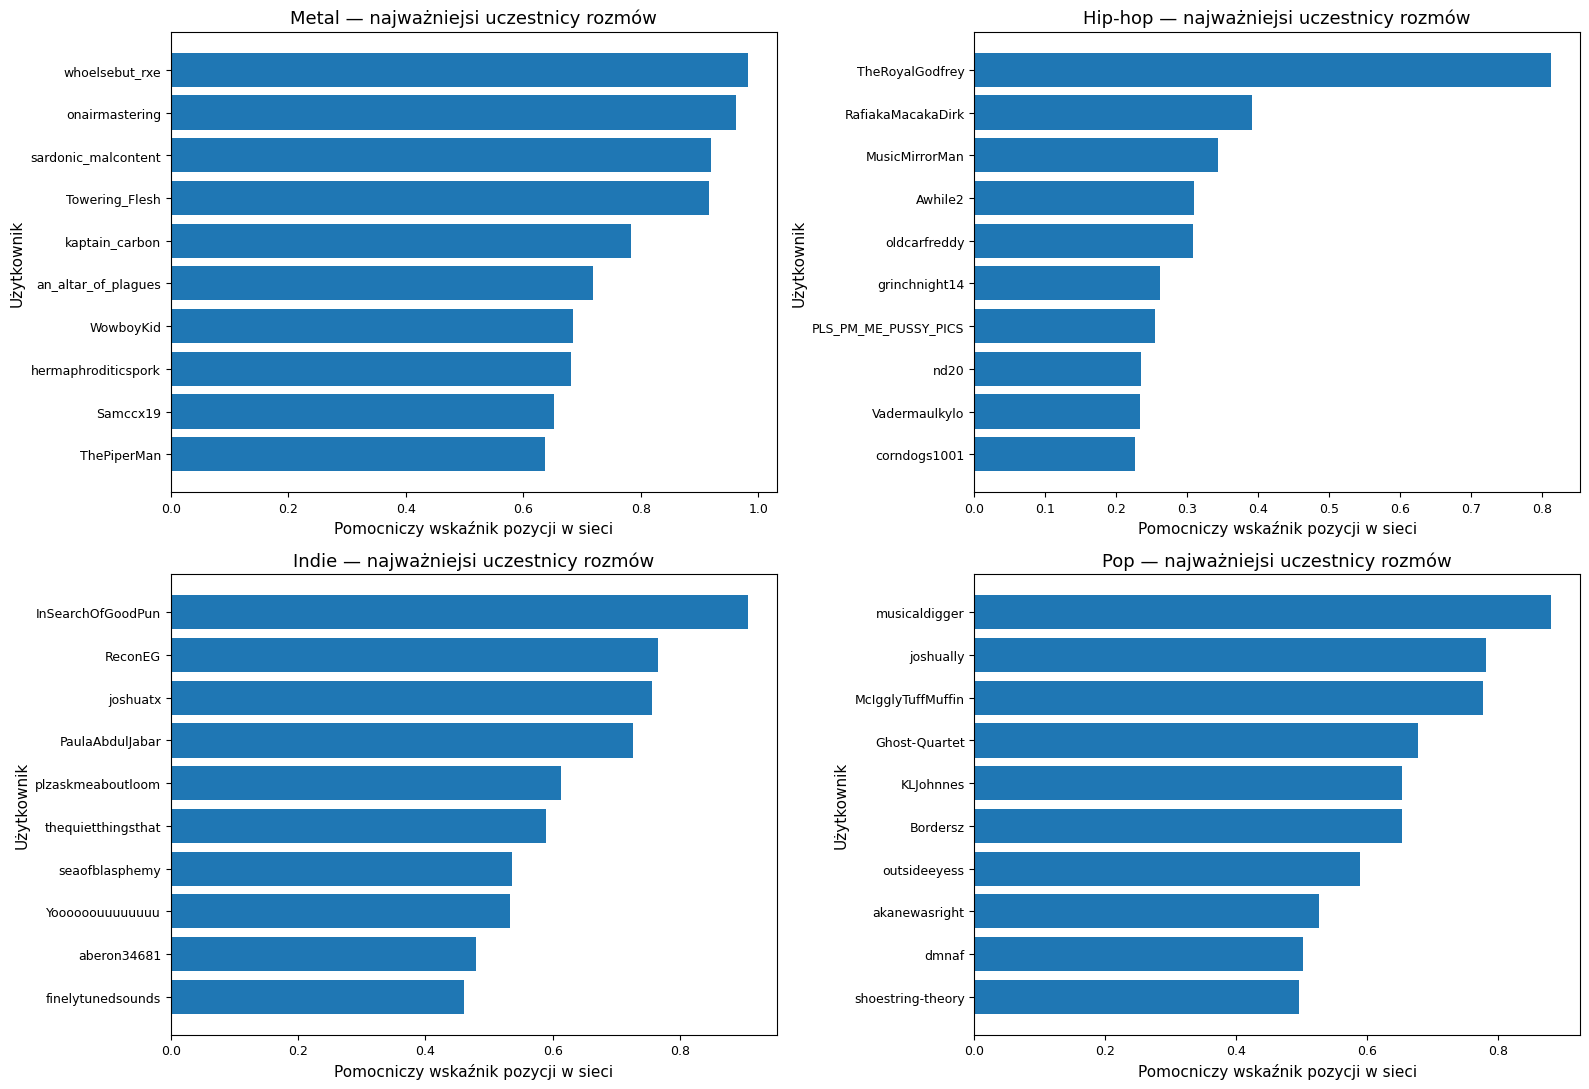

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, (subreddit, group) in zip(axes, sorted(top_influence_df.groupby('subreddit'))):
    top = group.sort_values('influence_score', ascending=True)
    ax.barh(top['author'], top['influence_score'])
    ax.set_title(f"{subreddit_display(subreddit)} — najważniejsi uczestnicy rozmów")
    ax.set_xlabel('Pomocniczy wskaźnik pozycji w sieci')
    ax.set_ylabel('Użytkownik')

for ax in axes[top_influence_df['subreddit'].nunique():]:
    ax.axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_structurally_central_users.png', dpi=150, bbox_inches='tight')
plt.show()

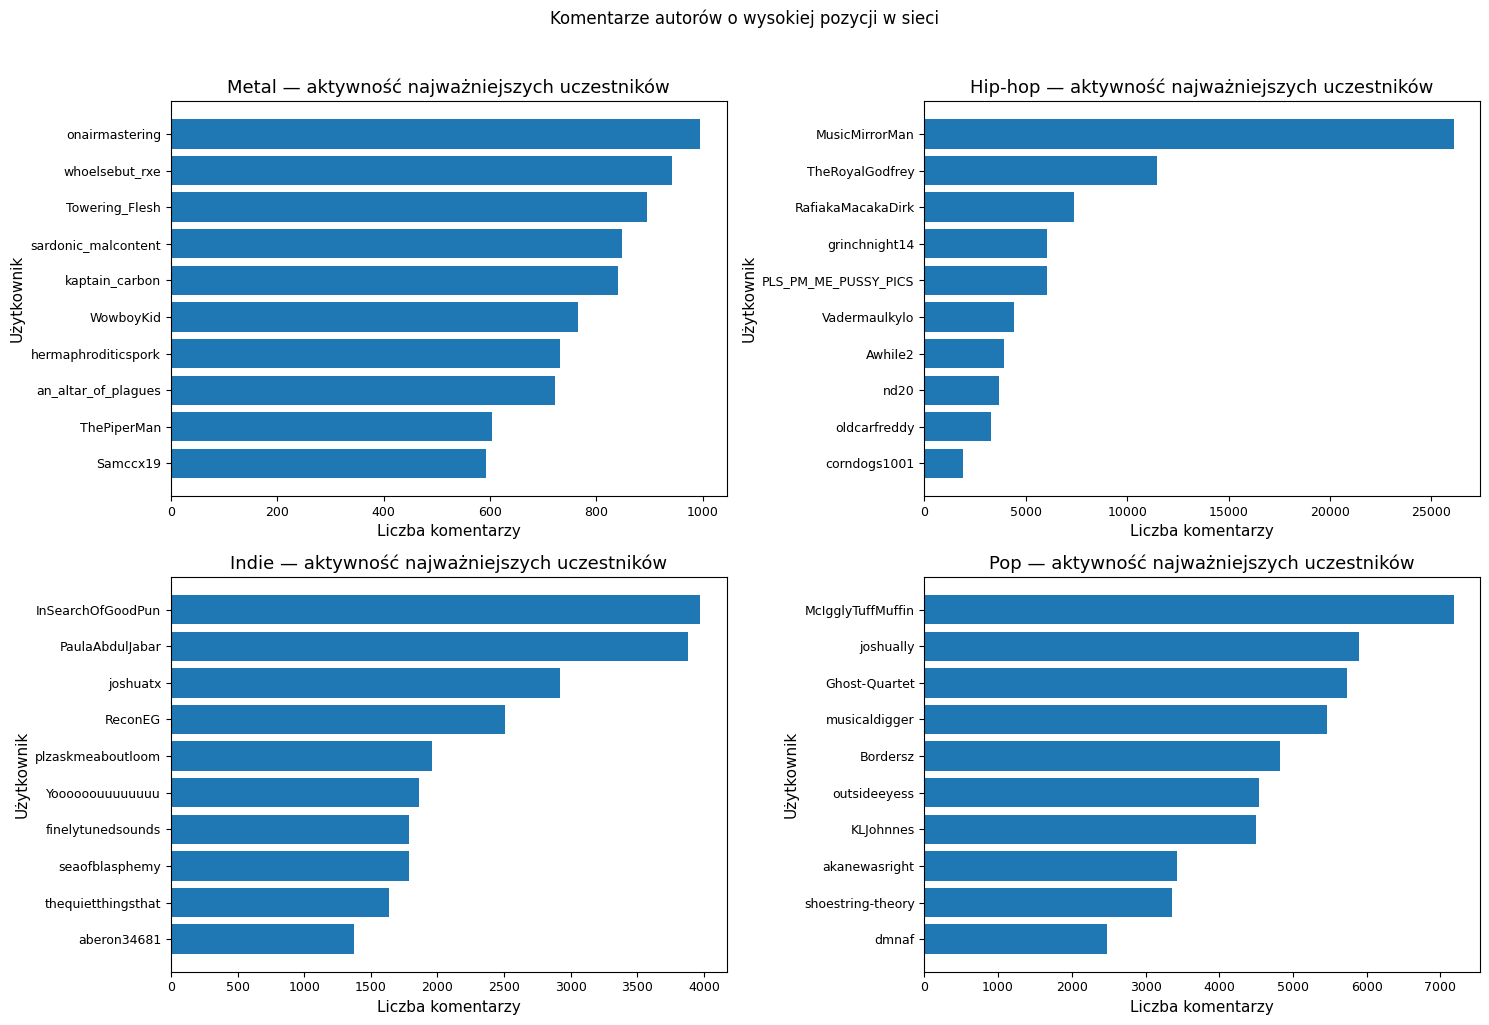

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, (subreddit, group) in zip(axes, sorted(top_influence_df.groupby('subreddit'))):
    top = group.sort_values('comment_count', ascending=True)
    ax.barh(top['author'], top['comment_count'])
    ax.set_title(f"{subreddit_display(subreddit)} — aktywność najważniejszych uczestników")
    ax.set_xlabel('Liczba komentarzy')
    ax.set_ylabel('Użytkownik')

for ax in axes[top_influence_df['subreddit'].nunique():]:
    ax.axis('off')

plt.suptitle('Komentarze autorów o wysokiej pozycji w sieci', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'centrality_vs_activity.png', dpi=150, bbox_inches='tight')
plt.show()

Najwyższy wynik pomocniczego wskaźnika centralności uzyskują użytkownicy łączący dużą aktywność komentarzową z wyraźną pozycją w grafie odpowiedzi. W interpretacji należy zachować ostrożność: wysoka pozycja w sieci nie musi oznaczać autorytetu, popularności ani pozytywnego odbioru przez społeczność.

## Wnioski z analizy sieci społecznościowych

Analiza sieciowa umożliwia spojrzenie na społeczności muzyczne Reddita nie tylko przez treść komentarzy, lecz także przez strukturę interakcji między użytkownikami. Graf odpowiedzi pokazuje, które społeczności mają bardziej rozproszony model rozmów, a które skupiają się wokół mniejszej liczby aktywnych uczestników.

Podstawowe statystyki sieci, takie jak liczba użytkowników, liczba relacji, gęstość i wielkość największej części grafu, pozwalają porównać intensywność komunikacji. Degree centrality wskazuje autorów mających wielu bezpośrednich partnerów rozmowy, a betweenness pomaga zauważyć użytkowników-pomosty, którzy łączą różne grupy dyskusyjne.

W części społeczności widoczne są grupy użytkowników częściej wchodzących ze sobą w interakcje. Można to interpretować jako lokalne kręgi rozmowy, np. wokół konkretnych tematów, artystów albo stylów uczestnictwa. Wyniki należy jednak czytać ostrożnie, ponieważ graf obejmuje tylko odpowiedzi w komentarzach, a nie bierne czytanie, głosowania ani jakość wypowiedzi.

## Reset środowiska po restarcie kernela

In [28]:
# =========================================================
# ODTWORZENIE ŚRODOWISKA — 03_network_analysis_uporzadkowany
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from collections import Counter, defaultdict
from itertools import combinations, permutations

try:
    from community import community_louvain

    LOUVAIN_AVAILABLE = True
except ImportError:
    community_louvain = None
    LOUVAIN_AVAILABLE = False

try:
    import plotly.graph_objects as go

    PLOTLY_AVAILABLE = True
except ImportError:
    go = None
    PLOTLY_AVAILABLE = False

# =========================
# Sciezki
# =========================

# Katalogi sa zdefiniowane w pierwszej komorce konfiguracyjnej.
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

NETWORK_DF_CHECKPOINT = CHECKPOINT_DIR / "network_df_checkpoint.pkl"

# =========================
# Ustawienia wykresów
# =========================

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
)

# =========================
# Wczytanie danych
# =========================

if NETWORK_DF_CHECKPOINT.exists():
    print("Wczytuję checkpoint ramki danych sieci...")
    df = pd.read_pickle(NETWORK_DF_CHECKPOINT)
    print(f"Wczytano df z checkpointu: {df.shape}")

elif DATA_PATH.exists():
    print("Wczytuję dane z CSV...")
    df = pd.read_csv(DATA_PATH)
    print(f"Wczytano df z CSV: {df.shape}")

    required_columns = {"author", "parent_id", "comment_id", "subreddit"}
    missing_columns = required_columns - set(df.columns)

    if missing_columns:
        raise ValueError(f"Brakuje wymaganych kolumn: {missing_columns}")

    print("Czyszczenie ramki danych sieci...")

    df = df.copy()
    df["author"] = df["author"].astype(str)
    df["parent_id"] = df["parent_id"].astype(str)
    df["comment_id"] = df["comment_id"].astype(str)
    df["subreddit"] = df["subreddit"].astype(str)

    bot_pattern = r"bot$|automod|moderator|transcrib|helper"

    valid_mask = (
        df["author"].notna()
        & ~df["author"].isin(["[deleted]", "[removed]", "nan", "None"])
        & ~df["author"].str.lower().str.contains(bot_pattern, regex=True, na=False)
    )

    df = df.loc[valid_mask].copy()

    print(f"Oczyszczono df: {df.shape}")

    df.to_pickle(NETWORK_DF_CHECKPOINT)
    print(f"Zapisano checkpoint df: {NETWORK_DF_CHECKPOINT}")

else:
    raise FileNotFoundError(f"Nie znaleziono pliku danych: {DATA_PATH}")

# =========================
# Podsumowanie
# =========================

summary = pd.DataFrame(
    {
        "wartość": [
            len(df),
            df["author"].nunique(),
            df["subreddit"].nunique(),
            ", ".join(subreddit_display(name) for name in sorted(df["subreddit"].unique())),
        ]
    },
    index=[
        "liczba komentarzy po czyszczeniu",
        "liczba unikalnych użytkowników",
        "liczba społeczności",
        "analizowane społeczności",
    ],
)

summary.to_csv(REPORTS_DIR / "network_dataset_summary.csv")

print("\nŚrodowisko odtworzone.")
print(f"LOUVAIN_AVAILABLE: {LOUVAIN_AVAILABLE}")
print(f"PLOTLY_AVAILABLE: {PLOTLY_AVAILABLE}")
print(f"FIGURES_DIR: {FIGURES_DIR}")
print(f"REPORTS_DIR: {REPORTS_DIR}")

display(summary)

Wczytuję checkpoint ramki danych sieci...
Wczytano df z checkpointu: (2541741, 10)

Środowisko odtworzone.
LOUVAIN_AVAILABLE: True
PLOTLY_AVAILABLE: True
FIGURES_DIR: ..\outputs\figures
REPORTS_DIR: ..\outputs\reports


,wartość
liczba komentarzy po czyszczeniu,2541741
liczba unikalnych użytkowników,201615
liczba społeczności,4
analizowane społeczności,"Metal, Hip-hop, Indie, Pop"
